In [ ]:
#importing  dataset from kagglehub 

%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\Kiran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Kiran\.cache\kagglehub\datasets\mohammadtalib786\retail-sales-dataset\versions\1


In [8]:
 
import os
files = os.listdir(path)
print(files)

['retail_sales_dataset.csv']


In [ ]:
import pandas as pd 
import numpy as np 
df=pd.read_csv(path + "/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
print("Descriptive Statistics:\n")
print(df.describe())

print("\nMode for each column:\n")
print(df.mode().iloc[0])

Descriptive Statistics:

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000

Mode for each column:

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amou

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
daily_sales = df.groupby('Date')['Total Amount'].sum()
print(daily_sales.head())

Date
2023-01-01    3600
2023-01-02    1765
2023-01-03     600
2023-01-04    1240
2023-01-05    1100
Name: Total Amount, dtype: int64


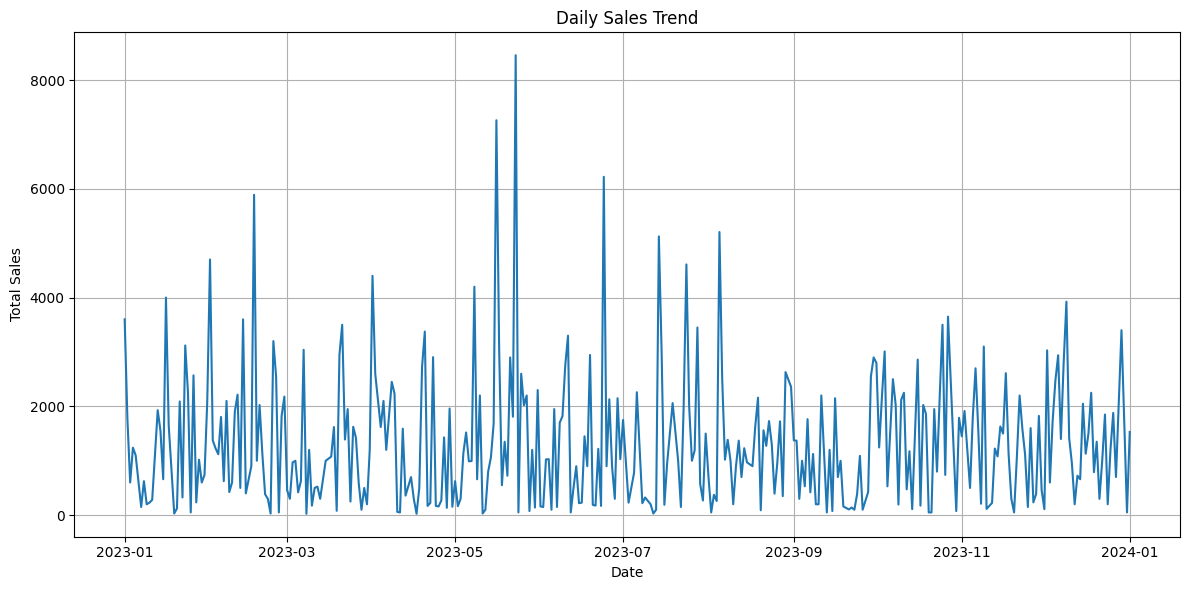

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(daily_sales)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose 
daily_sales.index = pd.to_datetime(daily_sales.index)  
decomposition = seasonal_decompose(daily_sales, model='additive', period=7)
print("Time series decomposition completed.")

Time series decomposition completed.


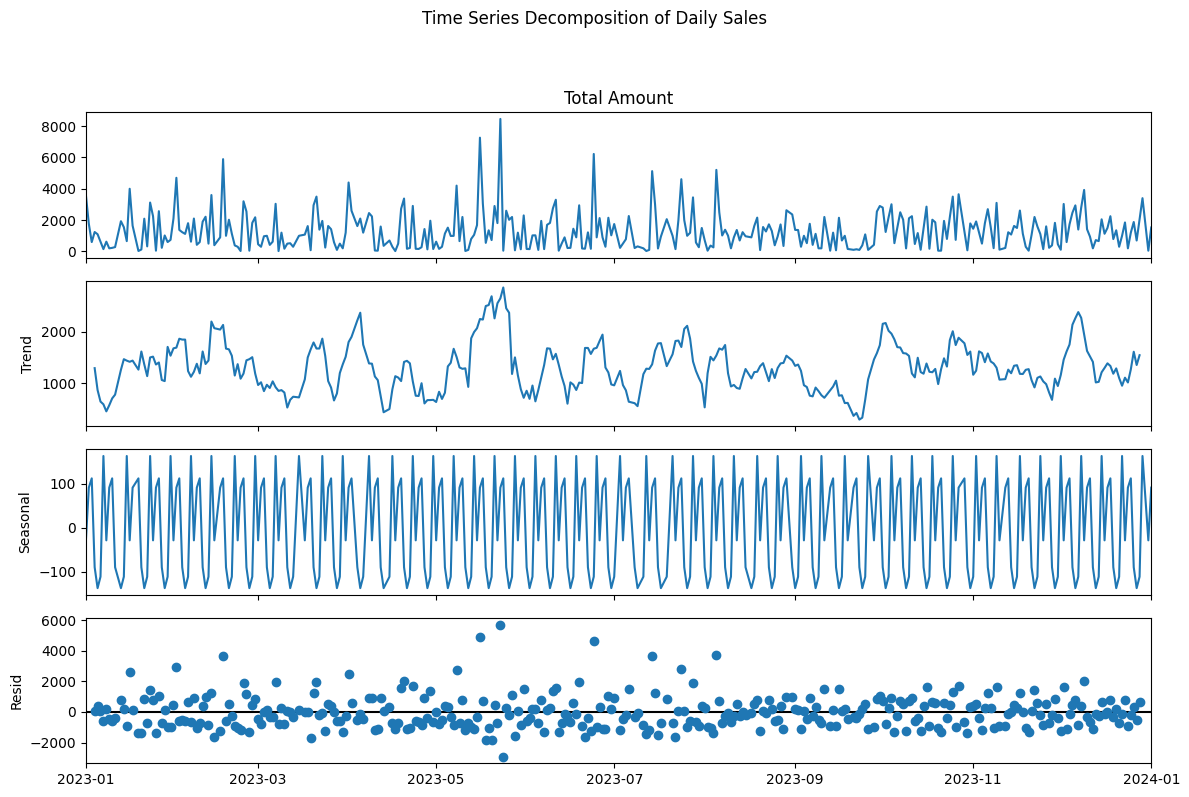

In [ ]:
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Daily Sales', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
gender_distribution = df['Gender'].value_counts()
print("Gender Distribution:")
print(gender_distribution)

Gender Distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64


In [ ]:
age_statistics = df['Age'].describe()
print("Age Demographics (Descriptive Statistics):\n", age_statistics)

Age Demographics (Descriptive Statistics):
 count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64


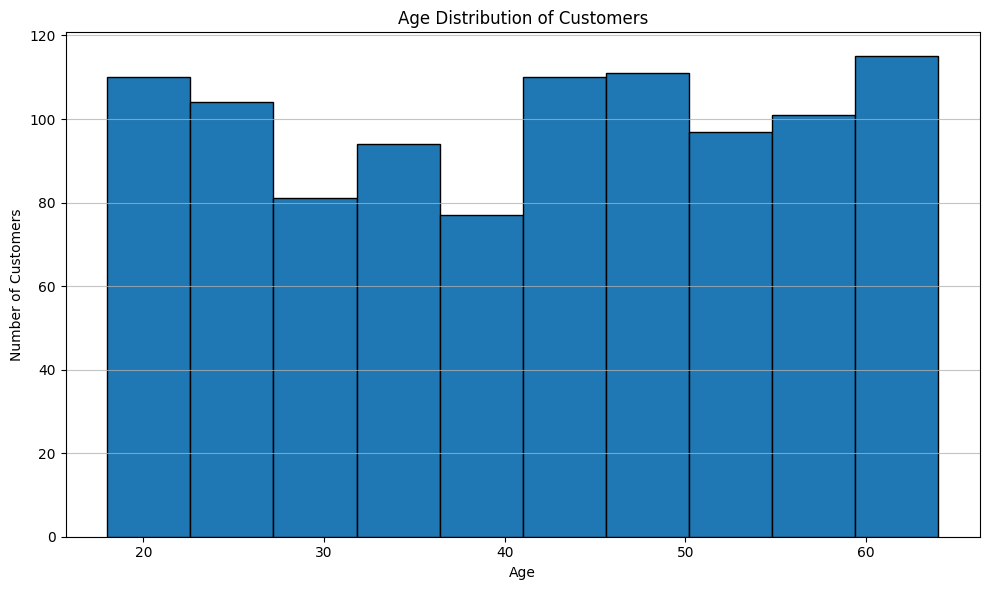

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=10, edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [ ]:
sales_by_category = df.groupby('Product Category')['Total Amount'].sum()
print("Total Sales by Product Category:")
print(sales_by_category)

Total Sales by Product Category:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


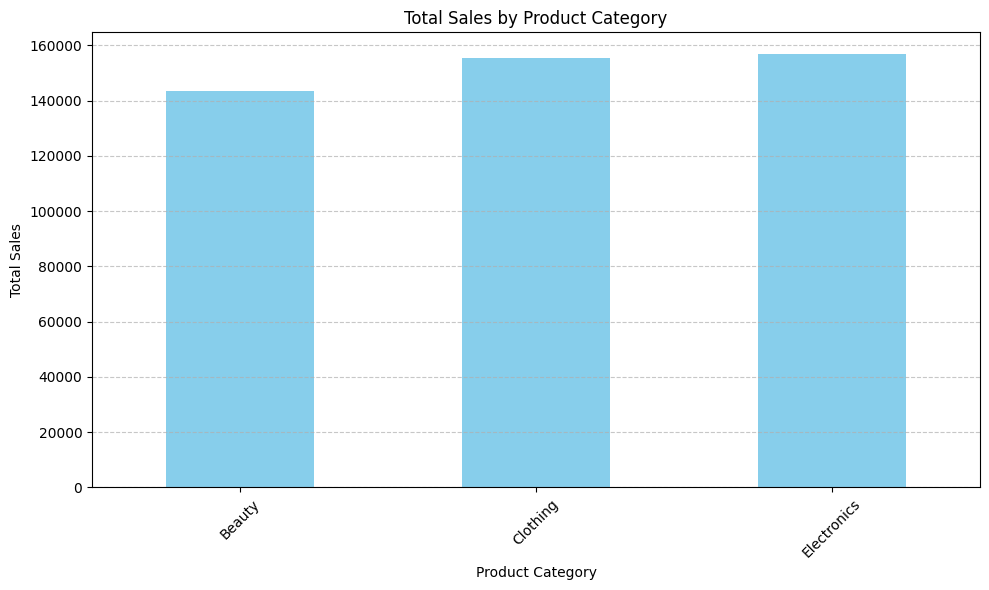

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sales_by_category.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
total_spending_by_gender = df.groupby('Gender')['Total Amount'].sum()
print("Total Spending by Gender:")
print(total_spending_by_gender)

Total Spending by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


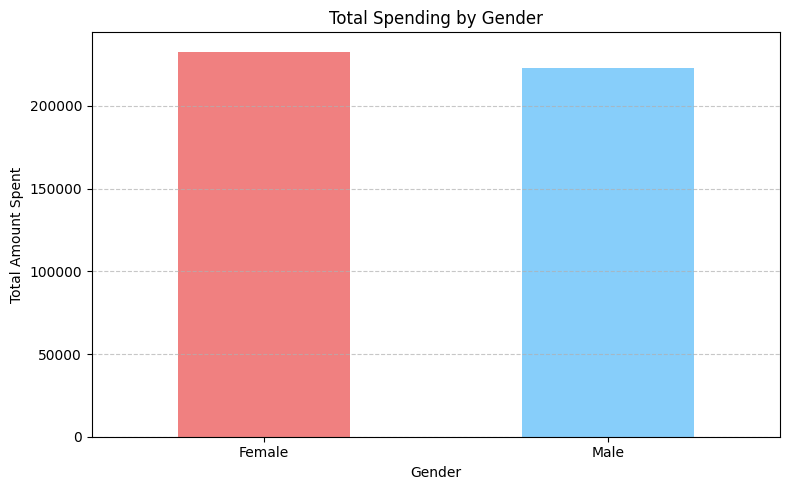

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
total_spending_by_gender.plot(kind='bar', color=['lightcoral', 'lightskyblue'])
plt.title('Total Spending by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
average_spending_by_gender = df.groupby('Gender')['Total Amount'].mean()
print("Average Spending by Gender:")
print(average_spending_by_gender)

Average Spending by Gender:
Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


In [ ]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print(df[['Age', 'Age Group']].head())

   Age Age Group
0   34     25-34
1   26     25-34
2   50     45-54
3   37     35-44
4   30     25-34


In [ ]:
spending_by_age_group = df.groupby('Age Group')['Total Amount'].sum()
print("Total Spending by Age Group:")
print(spending_by_age_group)

Total Spending by Age Group:
Age Group
18-24    74650
25-34    97090
35-44    96835
45-54    97235
55-64    90190
Name: Total Amount, dtype: int64


C:\Users\Kiran\AppData\Local\Temp\ipykernel_41836\3681394322.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spending_by_age_group = df.groupby('Age Group')['Total Amount'].sum()


In [ ]:
spending_by_age_group = df.groupby('Age Group', observed=False)['Total Amount'].sum()
print("Total Spending by Age Group:")
print(spending_by_age_group)

Total Spending by Age Group:
Age Group
18-24    74650
25-34    97090
35-44    96835
45-54    97235
55-64    90190
Name: Total Amount, dtype: int64


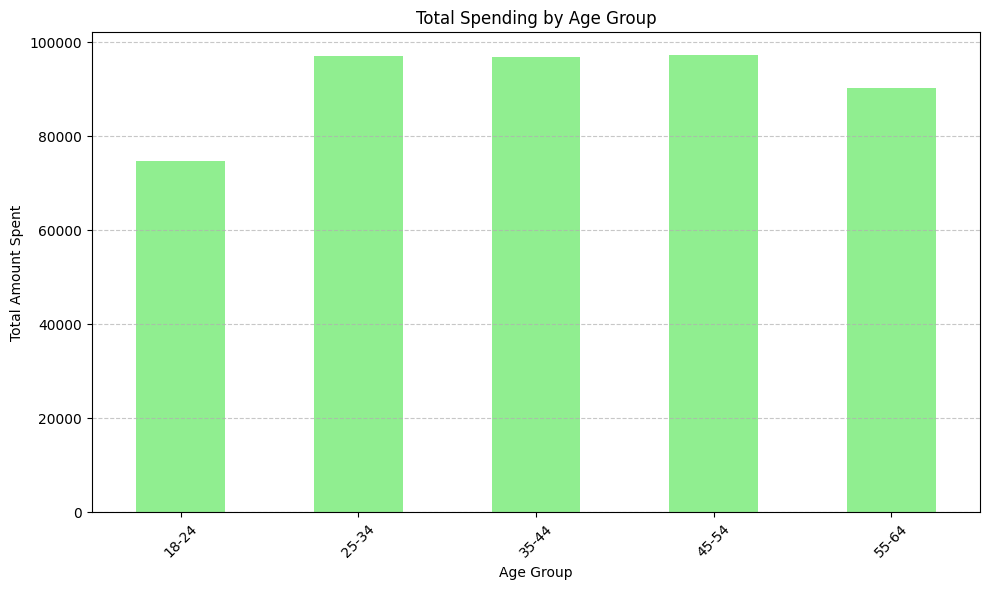

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
spending_by_age_group.plot(kind='bar', color='lightgreen')
plt.title('Total Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
category_sales_over_time = df.groupby(['Date', 'Product Category'])['Total Amount'].sum().reset_index()
print(category_sales_over_time.head())

         Date Product Category  Total Amount
0  2023-01-01           Beauty          1500
1  2023-01-01         Clothing          2100
2  2023-01-02           Beauty            25
3  2023-01-02         Clothing          1650
4  2023-01-02      Electronics            90


In [17]:
category_sales_pivot = category_sales_over_time.pivot(index='Date', columns='Product Category', values='Total Amount').fillna(0)
print(category_sales_pivot.head())

Product Category  Beauty  Clothing  Electronics
Date                                           
2023-01-01        1500.0    2100.0          0.0
2023-01-02          25.0    1650.0         90.0
2023-01-03         600.0       0.0          0.0
2023-01-04        1090.0     150.0          0.0
2023-01-05          50.0       0.0       1050.0


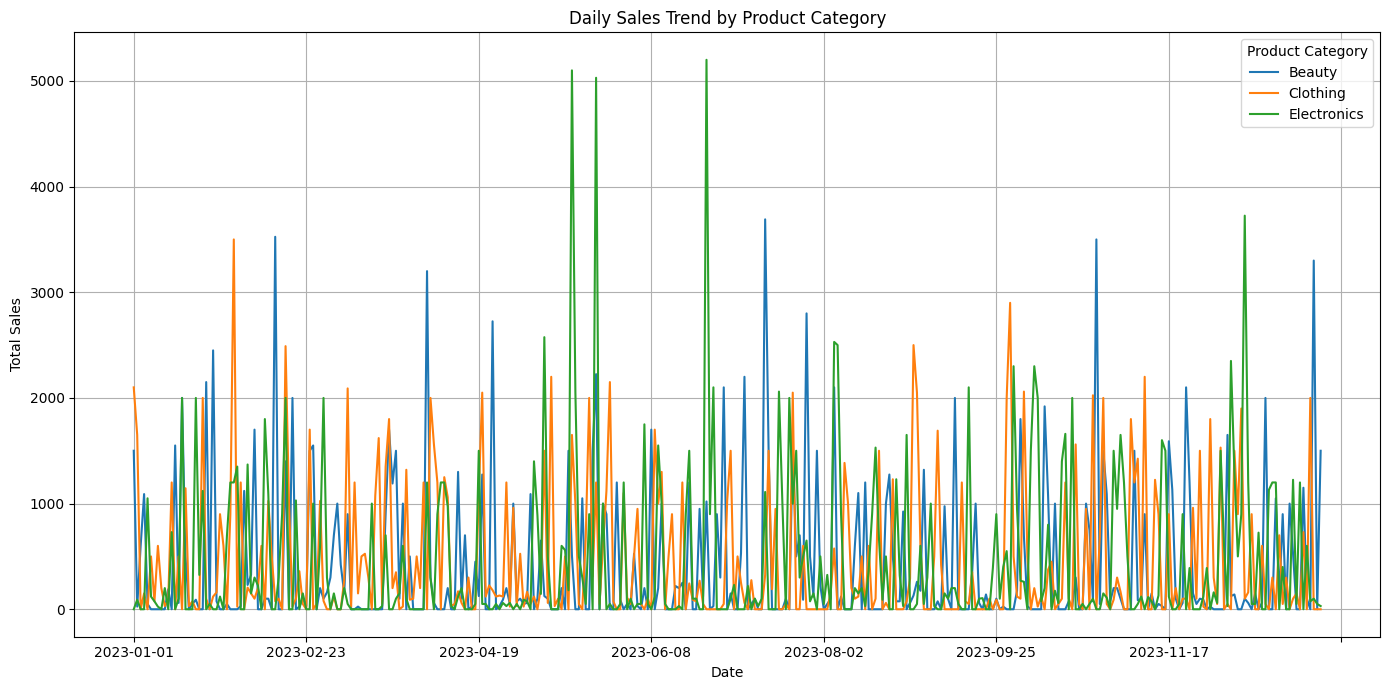

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
category_sales_pivot.plot(kind='line', ax=plt.gca())
plt.title('Daily Sales Trend by Product Category')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend(title='Product Category')
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
sales_by_gender_category = df.groupby(['Gender', 'Product Category'])['Total Amount'].sum()
print(sales_by_gender_category.head())

Gender  Product Category
Female  Beauty              74830
        Clothing            81275
        Electronics         76735
Male    Beauty              68685
        Clothing            74305
Name: Total Amount, dtype: int64


In [20]:
sales_by_gender_category_unstacked = sales_by_gender_category.unstack()
print(sales_by_gender_category_unstacked.head())

Product Category  Beauty  Clothing  Electronics
Gender                                         
Female             74830     81275        76735
Male               68685     74305        80170


<Figure size 1200x700 with 0 Axes>

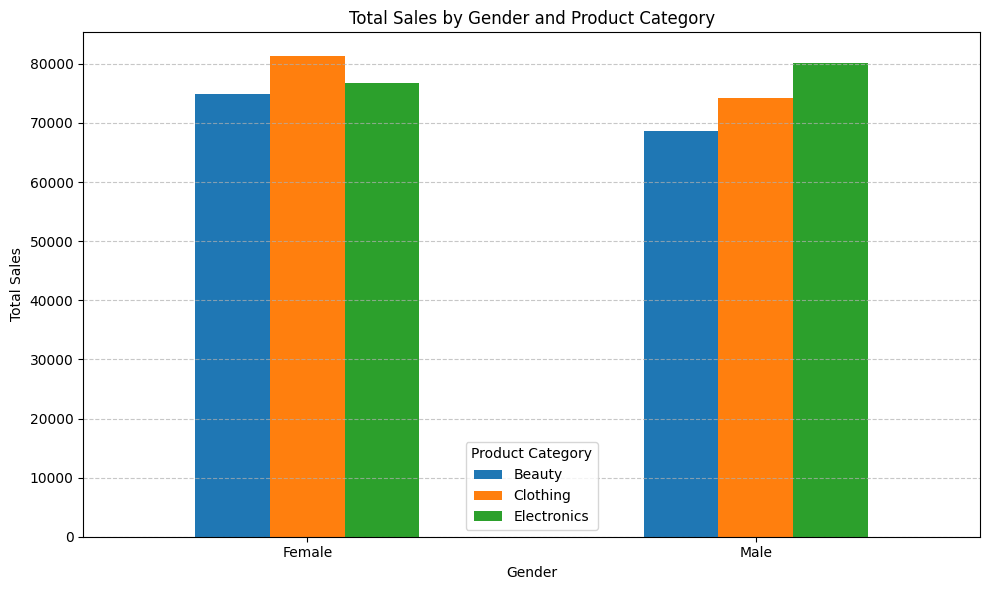

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sales_by_gender_category_unstacked.plot(kind='bar', figsize=(10, 6))
plt.title('Total Sales by Gender and Product Category')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Product Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
# Check what columns exist
print(df.columns.tolist())

# Look at first few rows
print(df.head())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [35]:
 # If you need to create an age grouping from raw age values
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 100], 
                        labels=['<18', '18-35', '35-50', '50-65', '65+'])

# Then run your groupby
spending_by_age_category = df.groupby(['AgeGroup', 'Product Category'], observed=False)['Total Amount'].sum()

<Figure size 1400x800 with 0 Axes>

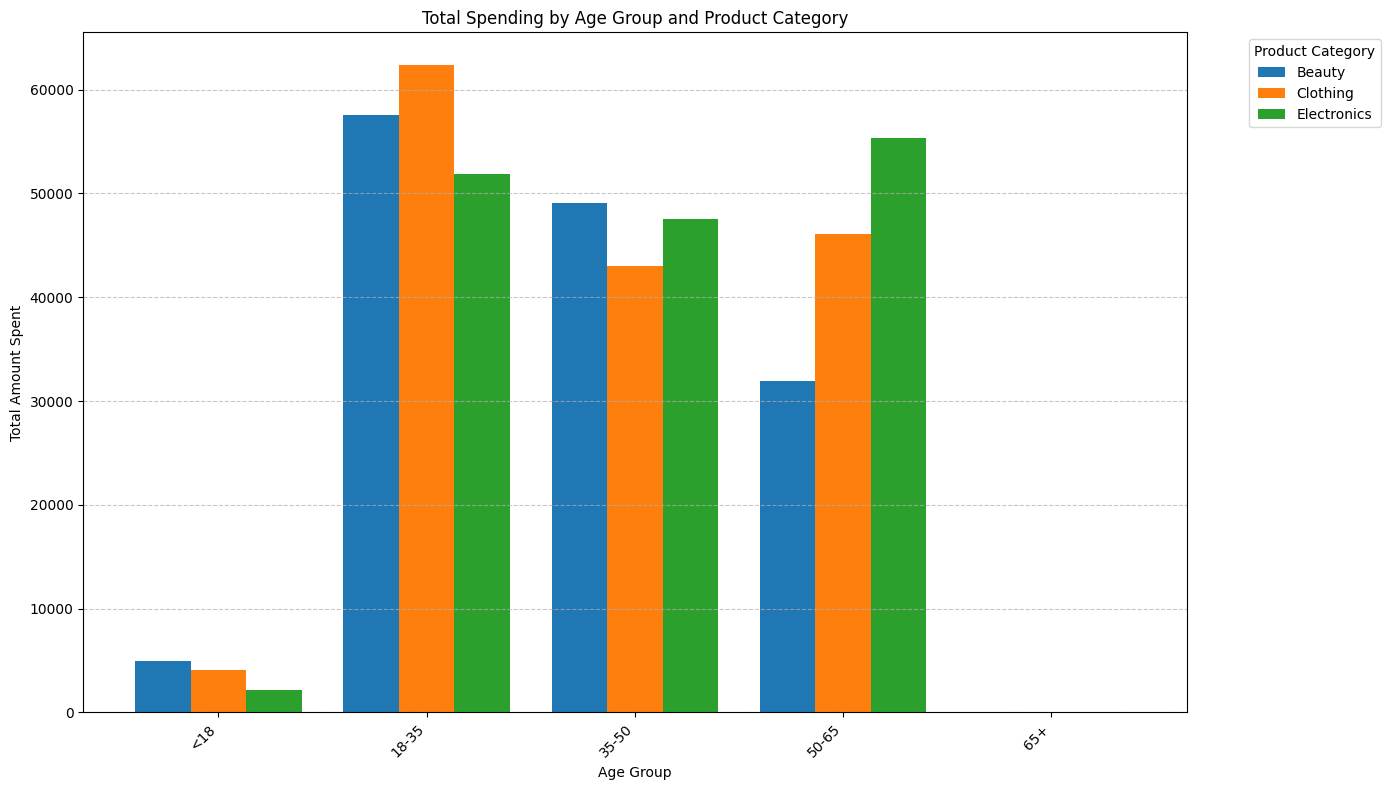

In [36]:
import matplotlib.pyplot as plt

spending_by_age_category_unstacked = spending_by_age_category.unstack()

plt.figure(figsize=(14, 8))
spending_by_age_category_unstacked.plot(kind='bar', figsize=(14, 8), width=0.8)
plt.title('Total Spending by Age Group and Product Category')
plt.xlabel('Age Group')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Date
2023-01-01    3600
2023-01-02    1765
2023-01-03     600
2023-01-04    1240
2023-01-05    1100
Name: Total Amount, dtype: int64
Time series decomposition completed.


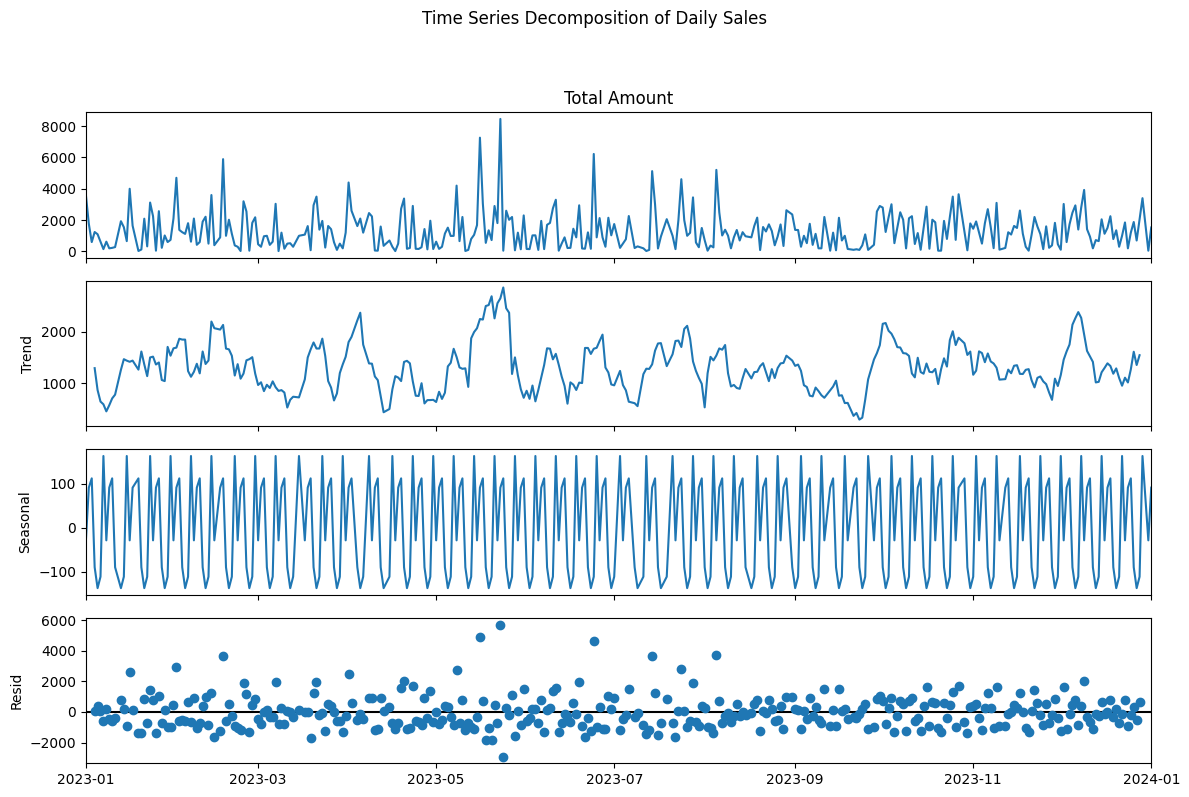

In [47]:
daily_sales = df.groupby('Date')['Total Amount'].sum()
print(daily_sales.head())

from statsmodels.tsa.seasonal import seasonal_decompose 

daily_sales.index = pd.to_datetime(daily_sales.index)  
decomposition = seasonal_decompose(daily_sales, model='additive', period=7)
print("Time series decomposition completed.")

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition of Daily Sales', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()